# Calculation general CME distributions in $\beta$

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [2]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

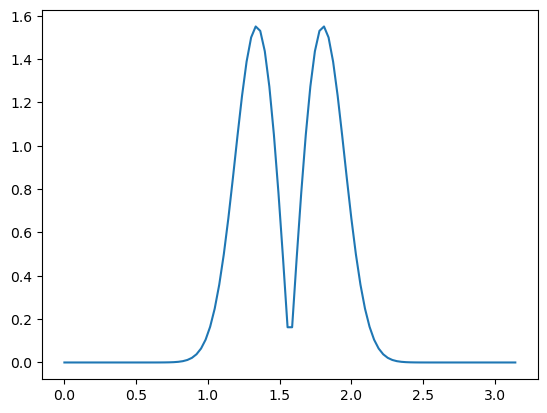

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$
For a proper description we refer to the associated paper.



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. We here under properly normalize the distribution!

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

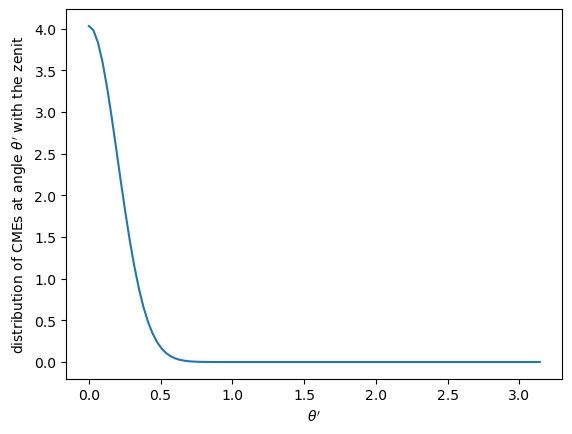

In [4]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

In [5]:
# general distribution for given tau
def get_sinphi2(theta, phi, theta2, beta):
    cosphi2 = (np.cos(beta)  - np.cos(theta)*np.cos(theta2) )/ (np.sin(theta)*np.sin(theta2)) 
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(beta, tau, vec=True):
    if vec:
        def integrand_vec(x):
            theta = x[0]
            phi = x[1]
            theta2 = x[2]
            return integrand(theta, phi, theta2, beta, tau)
        return integrand_vec
    else:
        def integrand2(theta, phi, theta2):
            return integrand(theta, phi, theta2, beta, tau)
        return integrand2

def integrand(theta, phi, theta2, beta, tau):
    sinphi2 = get_sinphi2(theta, phi, theta2, beta)
    alpha = get_alpha(tau, theta, phi)
    return    np.where(beta < theta - theta2, 0, np.where(beta > theta + theta2, 0, 
            np.sin(theta)**2 * rho(alpha) * np.sin(theta2)**2 * rho_CME(theta2) * sinphi2 
                                                ))

    # return np.sin(theta)**2 * rho(alpha) * np.sin(theta2)**2 * rho_CME(theta2) * sinphi2 


# def integrand(theta, phi, theta2, beta, tau):
#     sinphi2 = get_sinphi2(theta, phi, theta2, beta)
#     alpha = get_alpha(tau, theta, phi)
#     return np.where(beta < theta - theta2, 0, np.where(beta > theta + theta2, 0, 
#             np.sin(theta) * rho(alpha) * np.sin(theta2) * rho_CME(theta2) *\
#               ((np.sin(theta)  * np.sin(theta2))**2 - (np.cos(beta) - np.cos(theta) * np.cos(theta2))**2 +0.001)**0.5 
#                                                 ))

        

If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] \times [0,2\pi ]}d\theta d\phi d\theta' d\phi' \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

so we use $\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta$, or equivalently that
$\cos \phi' = \frac{\cos\beta - \cos\theta'\cos\theta}{\sin \theta'\sin\theta}$
to find that 


\begin{equation}
    \int d\phi'   \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta)) = \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'  \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta')  \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{\sin^2\theta\sin^2\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{\sin\theta\sin\theta'\sqrt{\sin^2 \theta \sin^2 \theta' - (\cos \beta - \cos \theta \cos \theta')^2 }}{|\sin\beta|}
\end{equation}


This calculation will take a while.



# intergral numerical

In [6]:
import time
# import mcint
import random
import math
from scipy.integrate import nquad

# epsabs=1e-10, epsrel=1e-10,

def sampler():
    while True:
        theta     = random.uniform(0, np.pi)
        phi  = random.uniform(0, 2*np.pi)
        theta2    = random.uniform(0, np.pi/2)
    
        yield (theta, phi, theta2)

def get_rho_beta(beta, tau):
    start_time = time.time()
    print(beta, tau, end='\r')
    result, error = nquad(f_integrand_(beta, tau, vec=False), [[0, np.pi],       # theta, phi, theta2
                                                [0, 2*np.pi],         # phi
                                                [0, np.pi / 2 ]], opts={"epsrel":0.05, 'epsabs':1e-2})       # theta2
    end_time = time.time()
    print(f'For params {beta=}, {tau = } we find the distibution to be {result/ (np.abs(np.sin(beta)) +0.001)}, with estimated error {error/ (np.abs(np.sin(beta)) +0.001)}. \
        Taking {(end_time-start_time):.2f} to calculate.')

    return result/ (np.abs(np.sin(beta)) +0.001)


def rho_betas(betas, tau):
    return np.array([get_rho_beta(beta, tau) for beta in betas])

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)

# for tau :
#     a = rho_betas(betas, tau, fast)
#     plt.plot(betas, a, label=fr'$\tau=${round(tau*180/np.pi)}°')
#     print(betas, a)

def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_betas(betas, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return np.array(dens)






# Sundist

In [7]:
from pathlib import Path

def get_or_create_data(name):
    filename = f'calculations/{name}.npy'
    file_path = Path(filename)

    
    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        # Replace this with your actual data generation logic
        data = run_taus(Taus)
        
        # Save the file so it exists next time
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")
        
    return data

dens = get_or_create_data("sundist")


File 'calculations/sundist.npy' found.


0.0 (6.283185307179588, 3.0015527959165525e-13)
0.39269908169872414 (6.283185269725044, 6.084386019439129e-08)
0.7853981633974483 (6.283185295494925, 2.4191430340664958e-08)
1.1780972450961724 (6.28318529055332, 3.749815596129032e-08)
1.5707963267948966 (6.283185307180058, 3.77118700711776e-08)


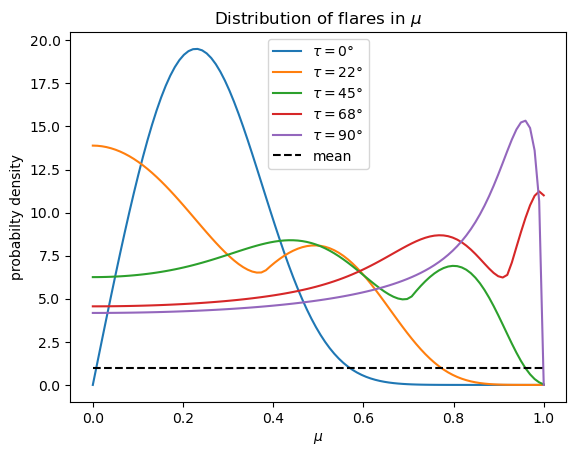

File 'calculations/sundist.npy' found.


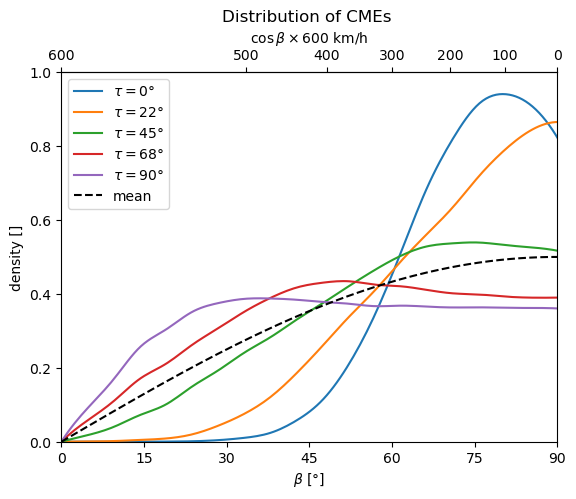

In [8]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline

def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()

Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("sundist")

def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_21380\817322620.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_21380\817322620.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


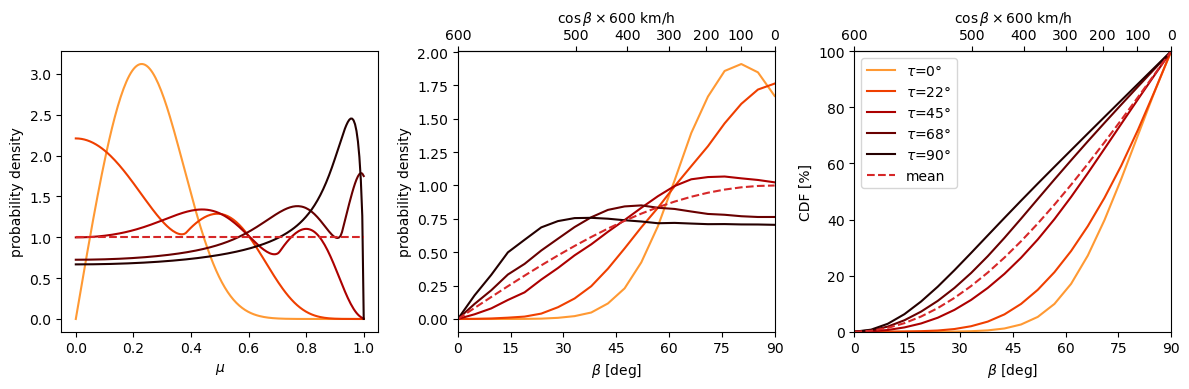

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --------------------------------------------------
# PHYSICS: define rho_mu at top level
# --------------------------------------------------
def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi))
    return 2 * quad(I, 0, 2*np.pi)[0]


# --------------------------------------------------
# PLOTTING FUNCTION (1x3) — NORMALIZED CME PDFs
# --------------------------------------------------
def plot_flare_cme_pdf_cdf_3x1(
    taus,
    betas,
    dens_list,
    beta2speed=None,
    speed2beta=None,
    n_mu=200,
    mu_min=0.0,
    mu_max=1.0,
    name="dist",
    loc=0,
    cmap_name="brg",
):
    taus = np.asarray(taus, dtype=float)
    mu = np.linspace(mu_min, mu_max, int(n_mu))

    betas = np.asarray(betas, dtype=float)
    dens_list = np.asarray(dens_list, dtype=float)

    # --- colormap setup ---
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.2, 0.9, len(taus)))

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

    # ==================================================
    # (1) Flare PDF in μ
    # ==================================================
    ax = axs[0]
    for c, tau in zip(colors, taus):
        y = np.array([rho_mu(m, tau) for m in mu], dtype=float)
        ax.plot(mu, y / np.average(y), color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    ax.plot(mu, np.ones_like(mu), "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("probability density")
    if loc == 0:
        ax.legend()

    # ==================================================
    # (2) CME PDF in β — NORMALIZED
    # ==================================================
    ax = axs[1]
    for c, d, tau in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d
        ax.plot(betas, d_pdf, color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    # mean PDF (isotropic)
    ax.plot(betas, np.sin(betas), "--", color="tab:red", label="mean")

    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("probability density")

    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/h')

    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)

    if loc == 1:
        ax.legend()

    # ==================================================
    # (3) CME CDF in β (from normalized PDFs)
    # ==================================================
    ax = axs[2]
    for c, d, tau in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d

        cdf = np.cumsum((d_pdf[:-1] + d_pdf[1:]) * 0.5 * np.diff(betas))
        cdf = np.concatenate(([0.0], cdf))
        ax.plot(betas, cdf * 100, color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    # analytic mean CDF
    mean_cdf = (1.0 - np.cos(betas)) * 100
    ax.plot(betas, mean_cdf, "--", color="tab:red", label="mean")

    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("CDF [%]")
    ax.set_ylim(0, 100)

    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/h')

    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)

    if loc == 2:
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"{name}.pdf")
    return fig, axs


# --------------------------------------------------
# USAGE
# --------------------------------------------------
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist1",
    loc=2,
    cmap_name="gist_heat_r",
)

plt.show()


# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

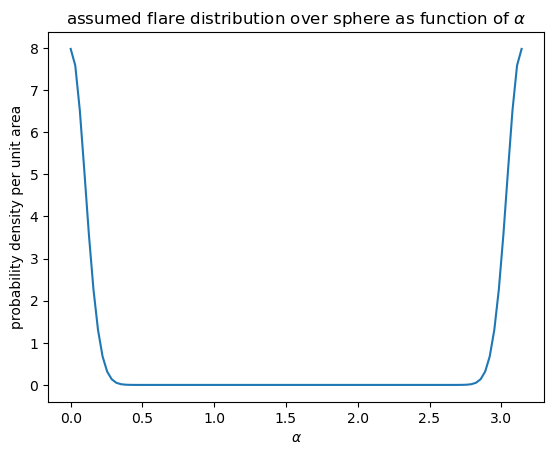

In [10]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [11]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()

0.0 (0.9993158136231646, 3.647190528409362e-12)
0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)
0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)
1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)
1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


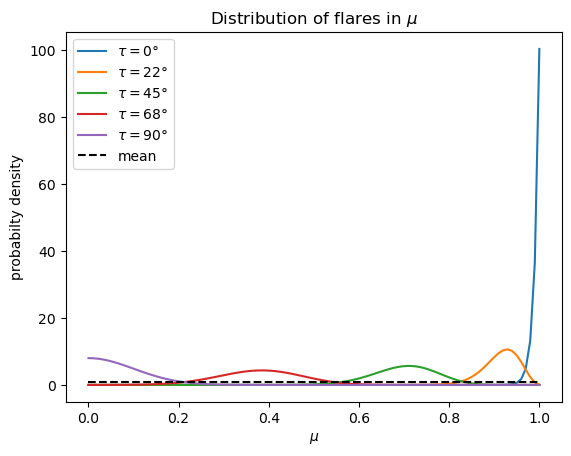

File 'calculations/polardist.npy' found.


In [12]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("polardist")


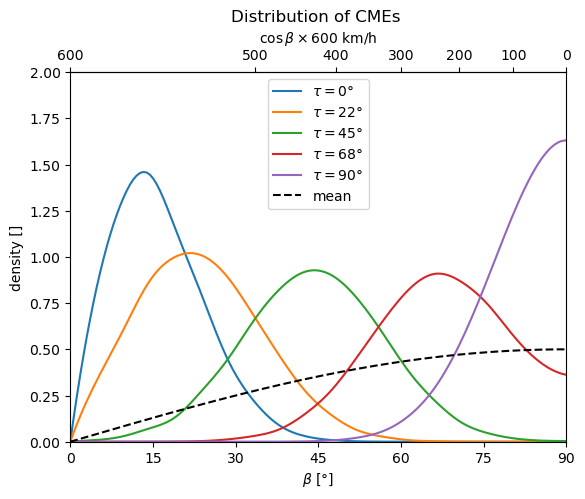

In [13]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,2)
    plt.show()

plotting_(dens, Taus)



C:\Users\mdewilde\AppData\Local\Temp\ipykernel_21380\817322620.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_21380\817322620.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


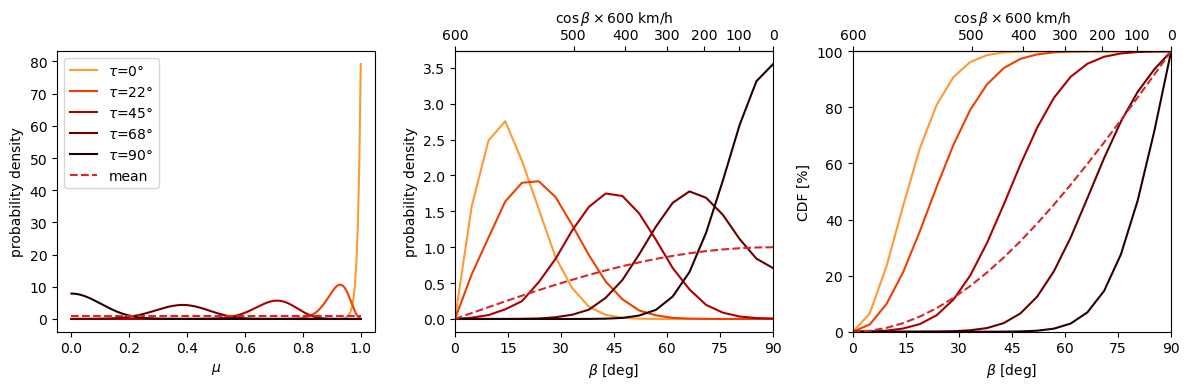

In [14]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist2",
    loc=0,
    cmap_name="gist_heat_r",
)

# flares around Equator (normal dist, no dip)

Text(0, 0.5, 'probability density per unit area')

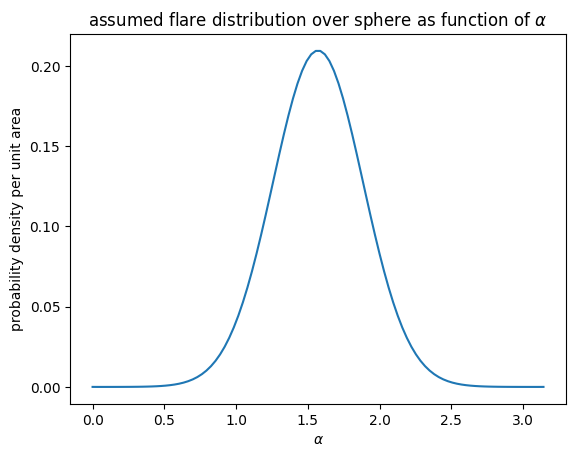

In [15]:
from scipy.stats import norm

def rho(alpha, loc=np.pi/2, scale = 0.3, err = 0.01):
    return norm.pdf(alpha, loc, scale) / 2 / np.pi / (np.sin(alpha) + err) 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.989596200027616, 5.042964046353404e-09)
0.39269908169872414 (0.9895961988532546, 1.5169831707718353e-09)
0.7853981633974483 (0.9895962002095553, 4.501296178332404e-09)
1.1780972450961724 (0.9895961876136867, 4.0982453815165865e-09)


/var/folders/v4/5s1hfr8d69ncw95jvfvw7t4c0000gn/T/ipykernel_78392/3779613015.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return 2 * quad(I, 0, 2*np.pi)[0]


1.5707963267948966 (0.989596200117882, 1.3436270065162358e-11)


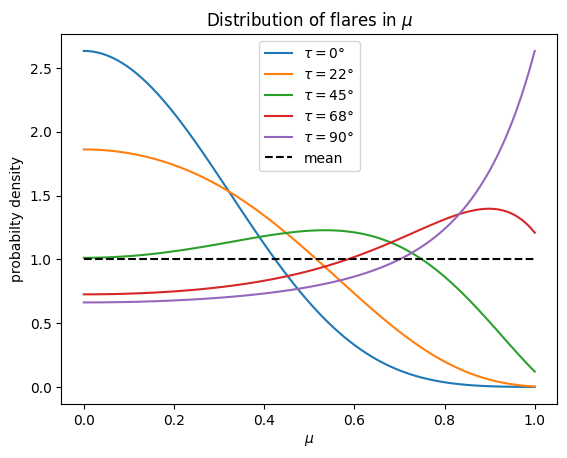

File 'calculations/equatornormaldist.npy' found.


In [16]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("equatornormaldist")


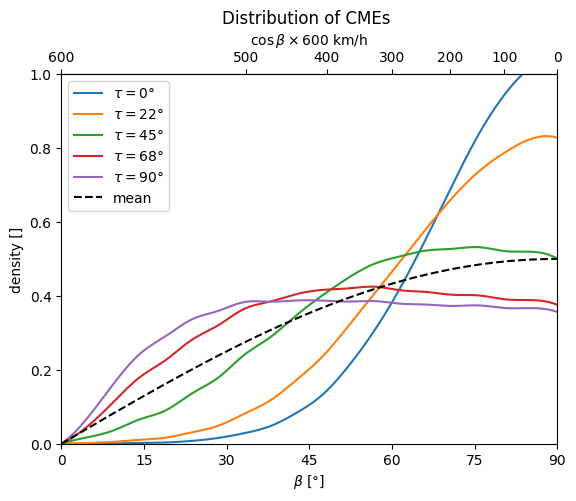

In [17]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



KeyboardInterrupt: 

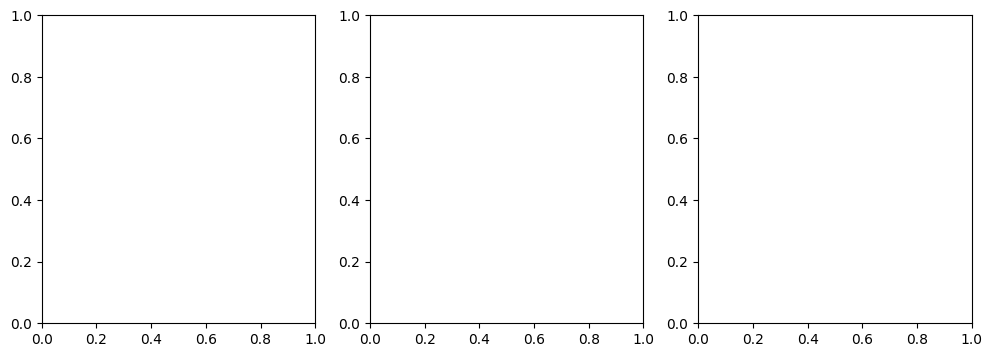

In [18]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist3",
    loc=2,
)

# Flares with stepfunction dist around equator

In [ ]:
def rho(alpha, h=30/180*np.pi):
    return np.where(np.abs(alpha-np.pi/2) < h, 1, 0)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [ ]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("blockdist")


In [ ]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



In [ ]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist4",
    loc=2,
)

In [ ]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist4",
    loc=2,
)

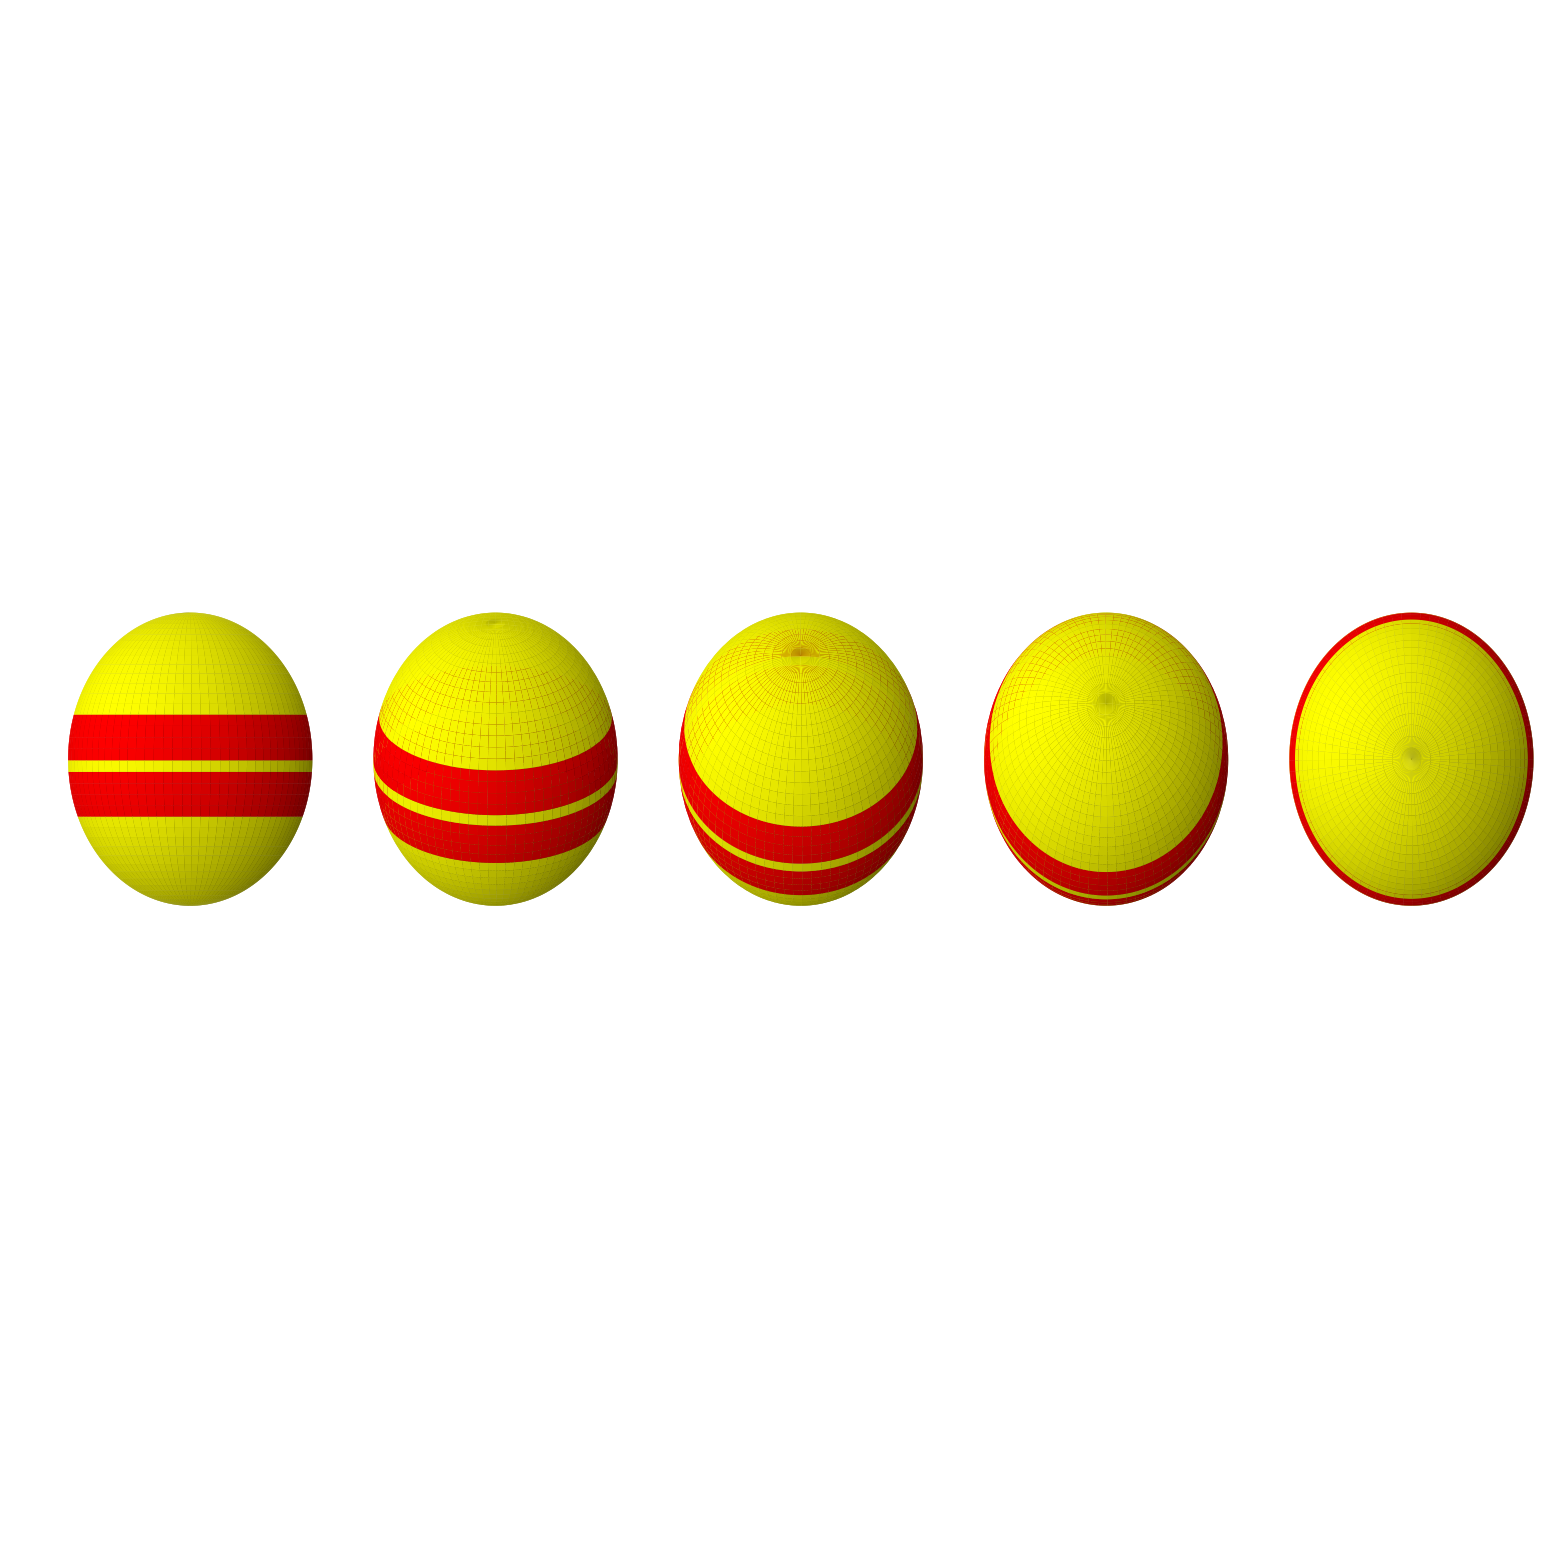

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

# ----------------------------
# parameters
# ----------------------------
r = 50  # radius

# higher resolution for smoother spheres
u, v = np.mgrid[0:2*np.pi:400j, 0:np.pi:200j]
x = r * np.cos(u) * np.sin(v)
y = r * np.sin(u) * np.sin(v)
z = r * np.cos(v)

# band colormap (yellow-red-yellow-red-yellow)
cmap_colors = ['yellow', 'red', 'yellow', 'red', 'yellow']
cmap = ListedColormap(cmap_colors)

# normalize v (colatitude) -> [0,1]
norm_v = (v - v.min()) / (v.max() - v.min())

# map near-equator region to red bands, rest to yellow (your original mapping)
color_indices = np.interp(
    norm_v,
    [0, 0.48, 0.49, 0.51, 0.52, 1],
    [0, 0.25, 0.5, 0.5, 0.75, 1]
)

# ----------------------------
# plot
# ----------------------------
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')

# your original elevations
elevations = [0, 22, 45, 68, 90]

for i, elev in enumerate(elevations):
    x_offset = i * 2.5 * r
    x_pos = x + x_offset

    # rotate around x-axis (changes y/z only)
    y_rot = y * np.cos(np.radians(elev)) - z * np.sin(np.radians(elev))
    z_rot = y * np.sin(np.radians(elev)) + z * np.cos(np.radians(elev))

    ax.plot_surface(
        x_pos, y_rot, z_rot,
        facecolors=cmap(color_indices),
        edgecolor='none',
        rstride=5, cstride=5
    )

ax.set_box_aspect([5, 1, 1])
ax.set_xlim(-r, 5 * r * 2.2)
ax.set_ylim(-r, r)
ax.set_zlim(-r, r)

# your original “orthographic-like” view
ax.view_init(elev=0, azim=-90)

ax.axis('off')
plt.savefig('globes.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


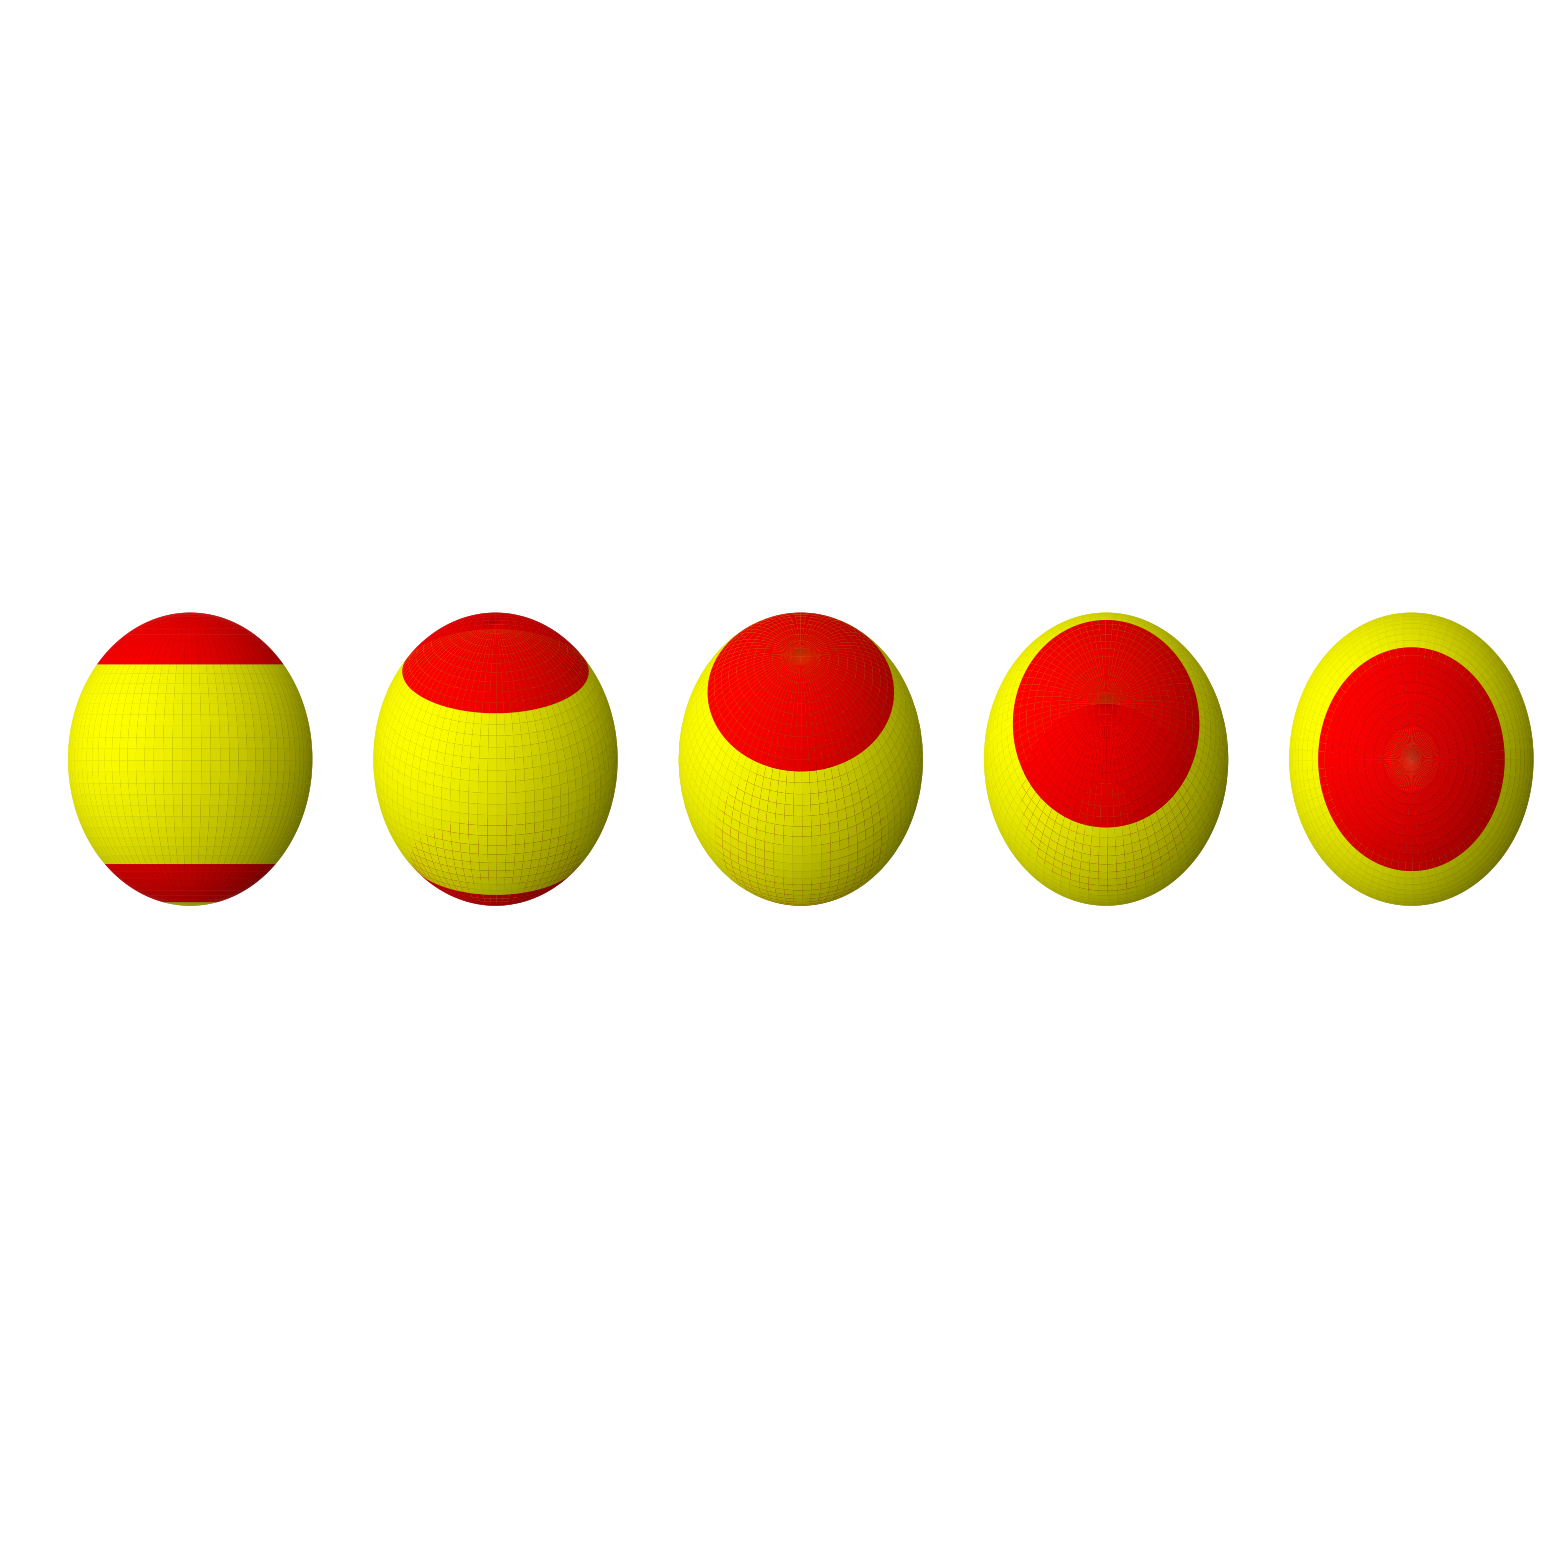

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

# ----------------------------
# parameters
# ----------------------------
r = 50  # radius

# higher resolution for smoother spheres
u, v = np.mgrid[0:2*np.pi:400j, 0:np.pi:200j]
x = r * np.cos(u) * np.sin(v)
y = r * np.sin(u) * np.sin(v)
z = r * np.cos(v)

# colormap (yellow-red-yellow-red-yellow)
cmap_colors = ['red', 'yellow', 'yellow', 'yellow', 'red']
cmap = ListedColormap(cmap_colors)

# normalize v (colatitude) -> [0,1]
norm_v = (v - v.min()) / (v.max() - v.min())

# ----------------------------
# NEW MAPPING: red at poles, yellow elsewhere
# desired: red - yellow - yellow - yellow - red
# ----------------------------
color_indices = np.interp(
    norm_v,
    [0.0, 0.1, 0.9, 1.0],   # transition widths; adjust 0.06/0.94 for thicker/thinner polar belts
    [1.0, 1.0, 0.0, 1.0]      # 1->red, 0->yellow (via your ListedColormap)
)

# ----------------------------
# plot
# ----------------------------
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')

# original elevations
elevations = [0, 22, 45, 68, 90]

for i, elev in enumerate(elevations):
    x_offset = i * 2.5 * r
    x_pos = x + x_offset

    # rotate around x-axis (changes y/z only)
    y_rot = y * np.cos(np.radians(elev)) - z * np.sin(np.radians(elev))
    z_rot = y * np.sin(np.radians(elev)) + z * np.cos(np.radians(elev))

    ax.plot_surface(
        x_pos, y_rot, z_rot,
        facecolors=cmap(color_indices),
        edgecolor='none',
        rstride=5, cstride=5
    )

ax.set_box_aspect([5, 1, 1])
ax.set_xlim(-r, 5 * r * 2.2)
ax.set_ylim(-r, r)
ax.set_zlim(-r, r)

# original “orthographic-like” view
ax.view_init(elev=0, azim=-90)

ax.axis('off')
plt.savefig('globes_polar_belts.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


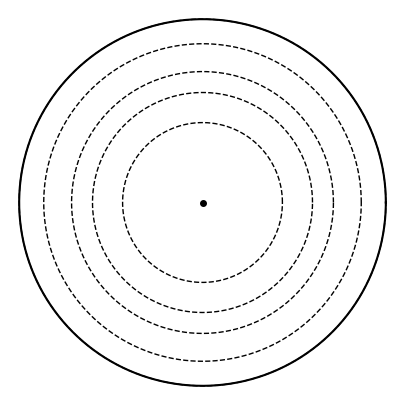

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# parameters
# ----------------------------
mu_levels = [1.0, 0.9, 0.8, 0.7, 0.5, 0.0]
npts = 1000

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(5, 5))

t = np.linspace(0, 2*np.pi, npts)

for mu in mu_levels:
    if mu == 1.0:
        # disk center
        ax.plot(0, 0, 'ko', ms=4)
    else:
        r = np.sqrt(1 - mu**2)
        x = r * np.cos(t)
        y = r * np.sin(t)
        ax.plot(x, y, 'k--', lw=1)

# outer limb (mu = 0)
ax.plot(np.cos(t), np.sin(t), 'k', lw=1.5)

# formatting
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.axis('off')

plt.savefig("mu_circles.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()
